## Assignment 1: Astronomy CNN

The GALAH Star Spectra Dataset contains 8,914 high-resolution stellar spectra, each with 16,384 flux measurements spanning the wavelength range from 4718 Å to 7890 Å. These spectra originate from the GALAH DR4 survey and are captured using four non-contiguous wavelength cameras (blue, green, red, and infrared), later concatenated into single spectra.

The data have been carefully calibrated and normalized to isolate the spectral lines that carry rich information about stellar properties. Each star is also associated with eight continuous labels—mass, age, bolometric luminosity, distance, effective temperature, surface gravity (\log g), metallicity ([Fe/H]), and signal-to-noise ratio—derived mainly by fitting simulated template spectra. The dataset is intended for machine learning applications, including label recovery, and is provided in .npy format for convenient loading and analysis.

Tasks

To get familiar with this dataset and PyTorch, complete the following tasks:

- Download the data
- Visualize a few spectra
- Implement a standard CNN to predict the three labels
- Visualize and document the performance


In [17]:
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
import helper

In [18]:
# Load the data

spectra = np.load(f"../data/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"../data/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

In [ ]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

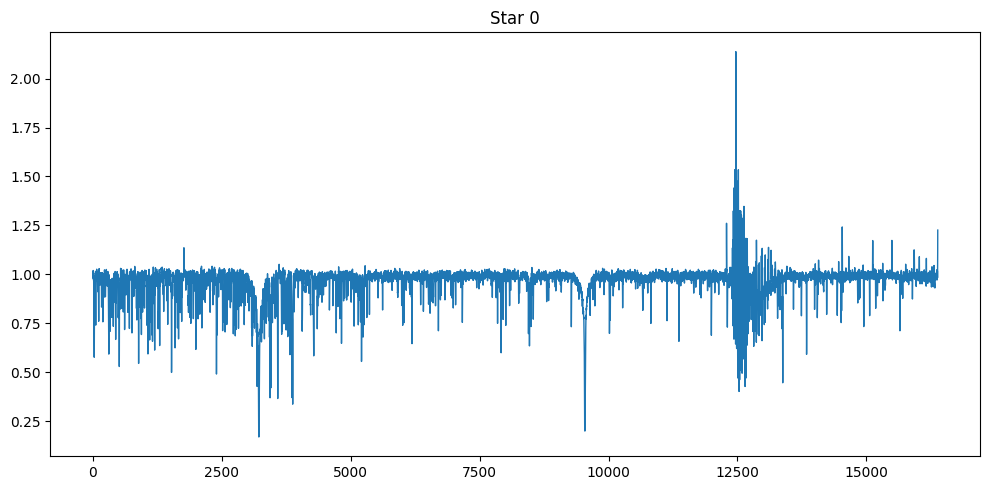

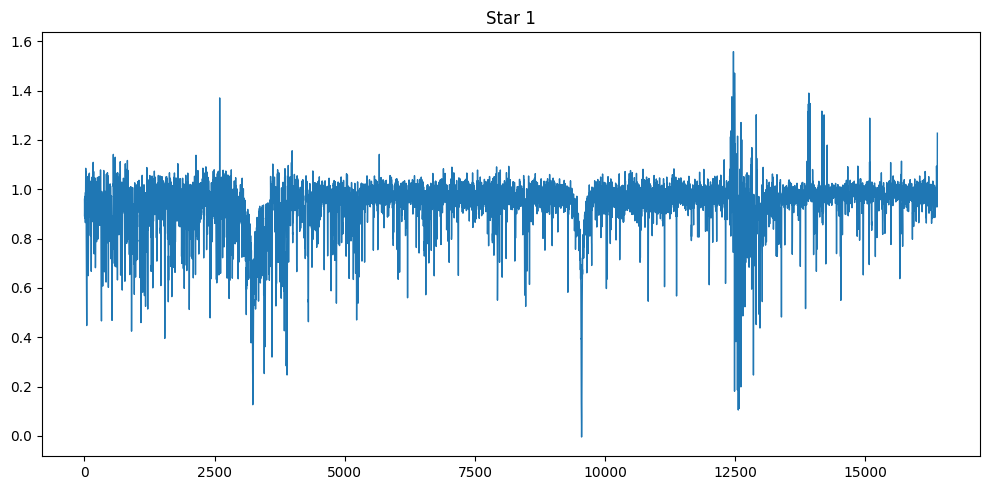

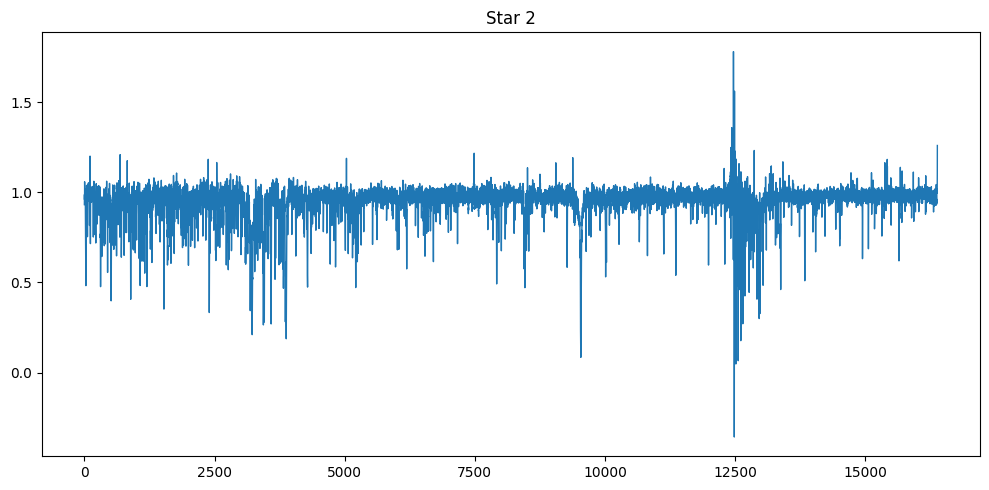

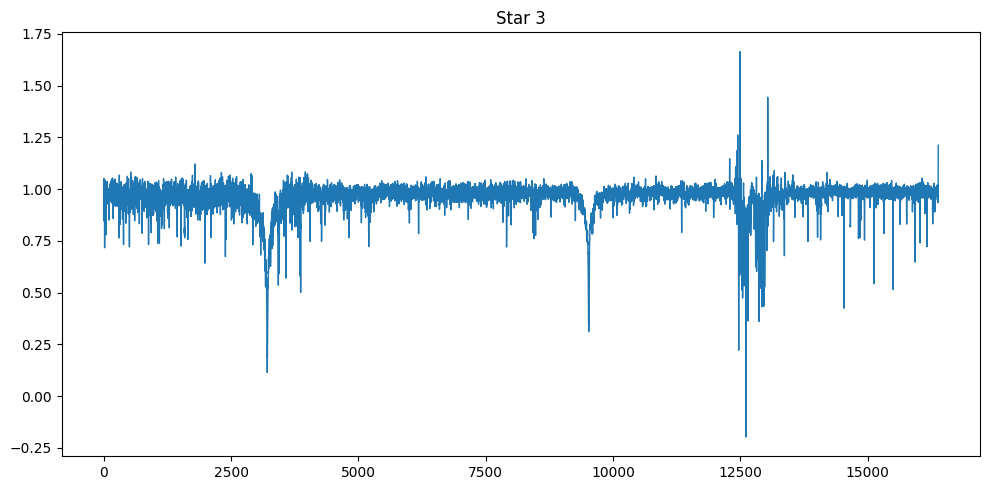

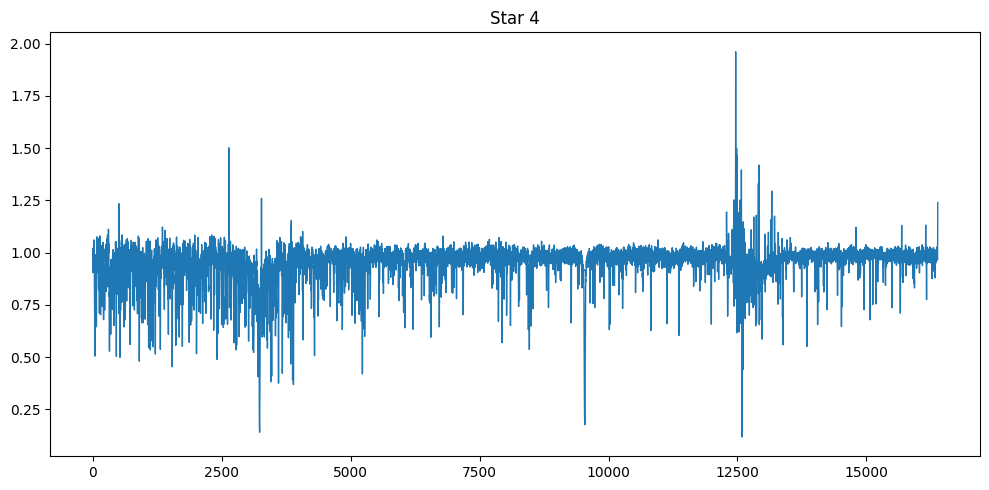

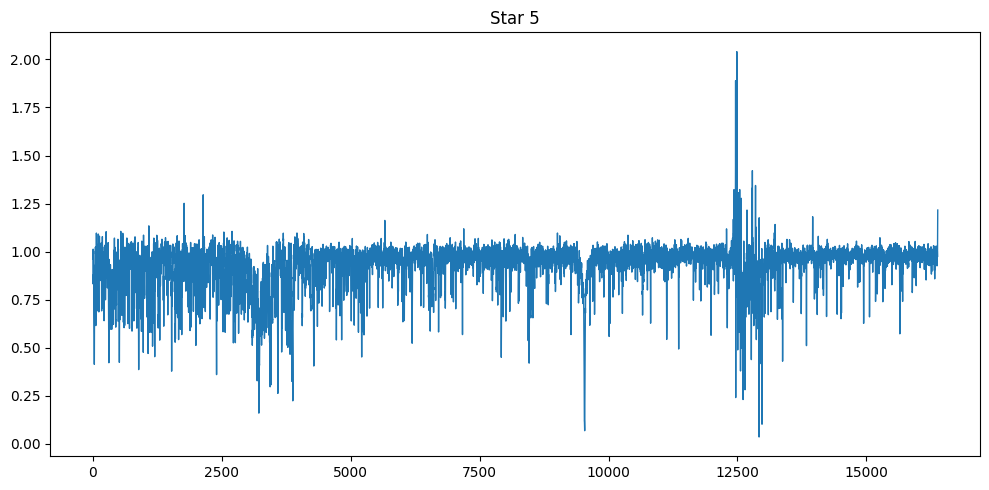

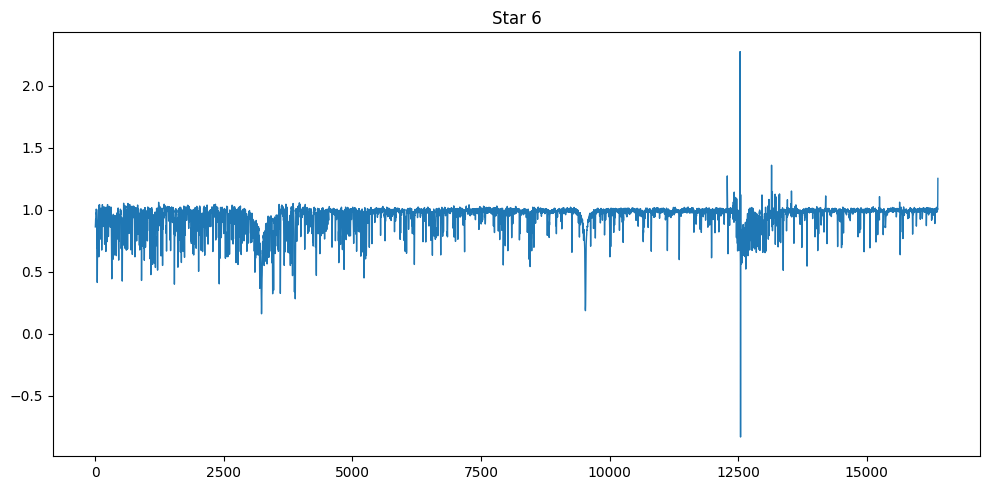

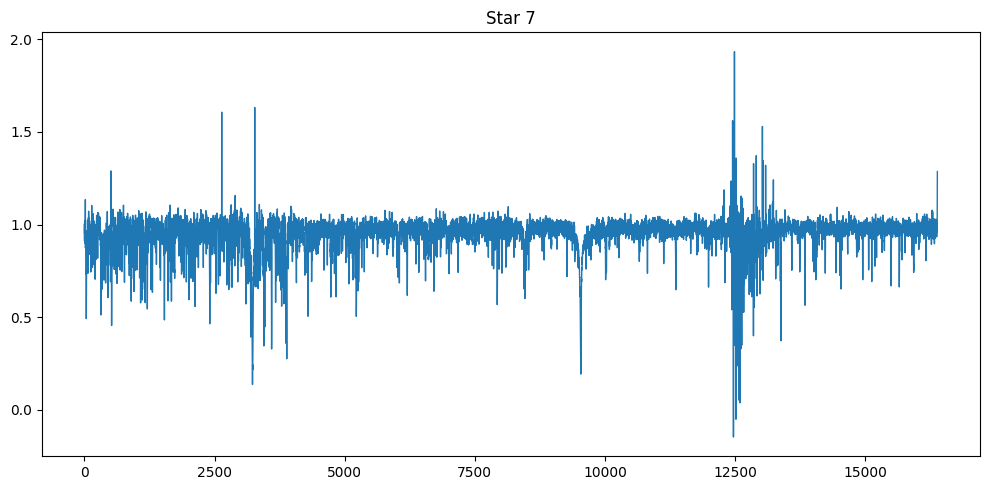

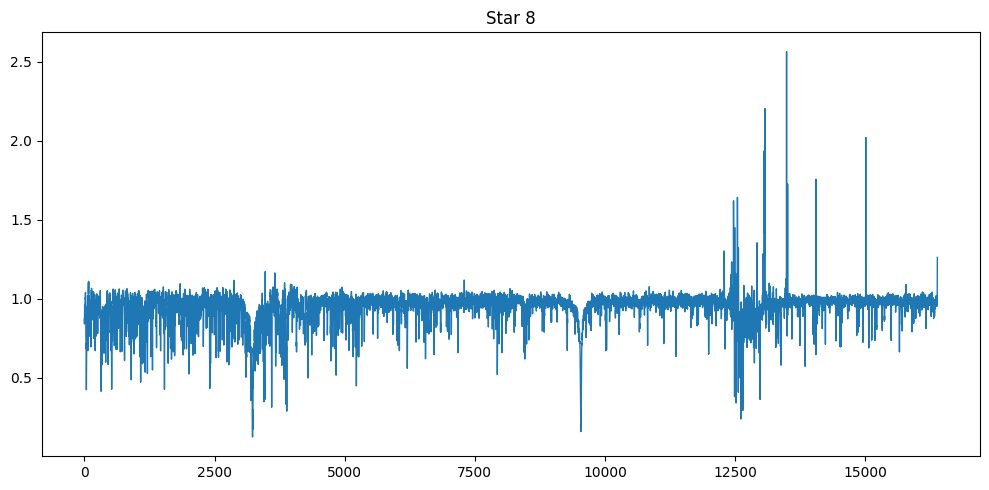

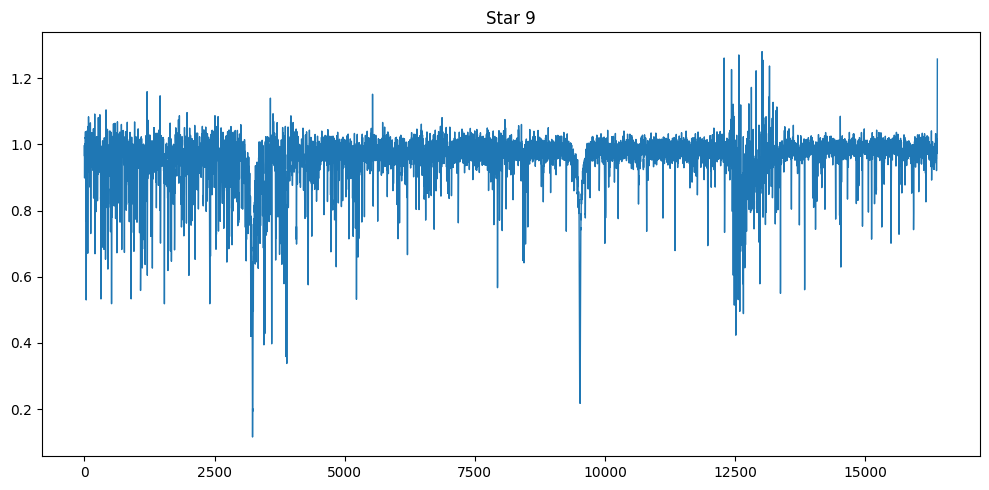

In [19]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i}")
  plt.tight_layout()

In [ ]:
# implement standard CNN to predict the three labels